In [96]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle
import pingouin as pg
from scipy.special import logit
import statsmodels.formula.api as smf

In [97]:
def fixPB12(master_df):
    # Fix PB12 with values from B12-partie_2
    # Define the segments to be replaced
    target_segments = ['stress2_MIST', 'nf2_2D']
    # Extract the "Source" data (from PB12-partie_2)
    # We make a .copy() to avoid modifying the original dataframe accidentally
    source_data = master_df[
        (master_df['Participant'] == 'PB12-partie_2') &
        (master_df['Segment'].isin(target_segments))].copy()
    # Change the ID in the source data to match the "Target" (PB12)
    source_data['Participant'] = 'PB12'
    # Remove the "Old/Corrupt" segments from the target (PB12)
    # This prevents the 'Duplicate entries' error in your delta function
    master_df = master_df.drop(
        master_df[
            (master_df['Participant'] == 'PB12') &
            (master_df['Segment'].isin(target_segments))
        ].index
    )
    # Append the "New" data from PB12-partie_2 into the master dataframe
    master_df = pd.concat([master_df, source_data], ignore_index=True)
    ## Optional: Remove the temporary 'PB12-partie_2' rows if you no longer need them
    master_df = master_df[master_df['Participant'] != 'PB12-partie_2']
    #print("Final segments for PB12:")
    #print(master_df.query("Participant == 'PB12'")['Segment'].unique())

In [98]:
def produce_normalized_metrics(master_df):
    log_metrics = ['EDA_Tonic_Mean', 'EDA_Tonic_SD', 'SCR_Peaks_Amplitude_Mean']
    for metric in log_metrics:
        if metric in master_df.columns:
            # Create a dataframe of just baselines
            baselines = master_df[master_df['Segment'].str.contains('baseline')].groupby('Participant')[metric].mean()
            # Map those baselines back to the main dataframe
            master_df['Participant_Baseline_' + metric] = master_df['Participant'].map(baselines)
            # Apply ln(1+x) to normalize the distribution of EDA/SCR
            master_df[metric] = np.log1p(master_df[metric]) - np.log1p(master_df['Participant_Baseline_' + metric])
        master_df[metric] = np.log1p(master_df[metric])

    # Get average baseline per participant for SCR_Frequency_PerMin
    scr_baselines = master_df[master_df['Segment'].str.contains('baseline')].groupby('Participant')['SCR_Frequency_PerMin'].mean()
    # Map those baselines back to the main dataframe
    master_df['SCR_Freq_Delta'] = np.sqrt(master_df['SCR_Frequency_PerMin']) - np.sqrt(master_df['Participant'].map(scr_baselines))
    master_df['SCR_Freq_Norm'] = np.sqrt(master_df['SCR_Frequency_PerMin'])

    sym_baselines = master_df[master_df['Segment'].str.contains('baseline')].groupby('Participant')['EDA_SympatheticN'].mean()
    # Map those baselines back to the main dataframe
    master_df['Sympathetic_Delta'] = logit(master_df['EDA_SympatheticN'].clip(0.001, 0.999)) - logit(master_df['Participant'].map(sym_baselines).clip(0.001, 0.999))
    #master_df['EDA_Sympathetic_Norm'] = np.log(master_df['EDA_SympatheticN'] + 1e-6)
    master_df['EDA_Sympathetic_Norm'] = np.log1p(master_df['EDA_SympatheticN'])

    # Get average baseline per participant for ECG
    ecg_baselines = master_df[master_df['Segment'].str.contains('baseline')].groupby('Participant')['ECG_Rate_Mean'].mean()
    # Map and subtract to get the "BPM Change"
    master_df['ECG_Delta_over_baseline'] = master_df['ECG_Rate_Mean'] - master_df['Participant'].map(ecg_baselines)

    # Get average baseline per participant for HRV (RMSSD)
    hrv_baselines = master_df[master_df['Segment'].str.contains('baseline')].groupby('Participant')['HRV_RMSSD'].mean()
    # Map and subtract to get the "ms Change"
    # Negative values = Reduced regulation (higher stress) | Positive values = Increased relaxation
    master_df['HRV_Delta_over_baseline'] = master_df['HRV_RMSSD'] - master_df['Participant'].map(hrv_baselines)
    #master_df['HRV_RMSSD_Norm'] = np.log(master_df['HRV_RMSSD'] + 1e-6) 
    master_df['HRV_RMSSD_Norm'] = np.log1p(master_df['HRV_RMSSD'])


In [99]:
def produce_deltas(master_df):
    # Define the metrics to calculate
    metrics = ["SCR_Freq_Norm", "EDA_Sympathetic_Norm", "HRV_RMSSD_Norm"]
    # Loop through each metric to create the reactivity scores
    for metric in metrics:
        # Filter for the specific segments to calculate the delta
        nf1_values = master_df[master_df['Segment'].str.contains('nf1')].set_index('Participant')[metric]
        nf2_values = master_df[master_df['Segment'].str.contains('nf2')].set_index('Participant')[metric]
        stress1_values = master_df[master_df['Segment'].str.contains('stress1')].set_index('Participant')[metric]
        stress2_values = master_df[master_df['Segment'].str.contains('stress2')].set_index('Participant')[metric]
        baseline_values = master_df[master_df['Segment'] == 'baseline'].set_index('Participant')[metric]
        # Calculate the difference: Stress1 - Nf1
        diff_series1 = nf1_values - baseline_values
        diff_series2 = nf2_values - baseline_values
        # Create the new metric name (e.g., 'SCR_Freq_Norm_reactivity')
        diff_col_name = f"{metric}_delta"
        # Initialize the column with NaN
        master_df[diff_col_name] = np.nan
        # Map the nf1 calculated differences to the 'nf1' rows
        mask1 = master_df['Segment'].str.contains('nf1')
        master_df.loc[mask1, diff_col_name] = master_df.loc[mask1, 'Participant'].map(diff_series1)
        # Map the nf2 calculated differences to the 'nf2' rows
        mask2 = master_df['Segment'].str.contains('nf2')
        master_df.loc[mask2, diff_col_name] = master_df.loc[mask2, 'Participant'].map(diff_series2)

    # Check the result for the first participant's nf1 row
    print(master_df[master_df['Segment'].str.contains('nf1')][['Participant', 'Segment'] + [f"{m}_delta" for m in metrics]].head())
    # Check the result for the first participant's nf2 row
    print(master_df[master_df['Segment'].str.contains('nf2')][['Participant', 'Segment'] + [f"{m}_delta" for m in metrics]].head())

In [100]:
def main():
    # Unpickling (deserializing) from a file
    with open('../dfmaster.pkl', 'rb') as f:
        master_df = pickle.load(f)

    fixPB12(master_df)
    produce_normalized_metrics(master_df)
    produce_deltas(master_df)
    #analysis_of_deltas_with_groups(master_df)
    LMM_Condition_vrfirst_abbafirst_phase(master_df)
    #LMM_Condition_x_vrfirst_abbafirst_phase(master_df)
    return 0

In [101]:
def LMM_Condition_vrfirst_abbafirst_phase(master_df):
    import statsmodels.formula.api as smf
    clean_df = master_df.copy()
    # Select rows where 'baseline' is NOT in the Segment string
    clean_df = clean_df[~clean_df['Segment'].str.contains('baseline', case=False, na=False)]
    #clean_df['Baseline'] = clean_df['Segment'].apply(lambda x: 'baseline' if 'baseline' in x else 'not_baseline')
    clean_df['Condition'] = clean_df['Segment'].apply(lambda x: 'VR' if 'VR' in x else '2D')
    # Try to use linearly independent conditions
    # Identify participants who have at least one segment named 'nf1_VR'
    vr_first_participants = clean_df.loc[clean_df['Segment'] == 'nf1_VR', 'Participant'].unique()
    # Create the column: If the participant is in that list, mark all their rows as 'VRfirst'
    clean_df['vrfirst'] = clean_df['Participant'].apply(
        lambda x: 'VRfirst' if x in vr_first_participants else 'VRlast'
    )
    # Identify participants who have at least one segment named 'stress1_ABBA'
    abba_first_participants = clean_df.loc[clean_df['Segment'] == 'stress1_ABBA', 'Participant'].unique()
    # Create the column: If the participant is in that list, mark all their rows as 'ABBAfirst'
    clean_df['abbafirst'] = clean_df['Participant'].apply(
        lambda x: 'ABBAfirst' if x in abba_first_participants else 'ABBAlast'
    )
    # Define the conditions
    conditions = [
        clean_df['Segment'].str.contains('nf1', case=False, na=False),
        clean_df['Segment'].str.contains('nf2', case=False, na=False)
    ]
    # Define the corresponding values
    choices = ['phase1', 'phase2']
    # Create the column (default to 'other' if neither nf1 nor nf2 is found)
    clean_df['Phase'] = np.select(conditions, choices, default='other')
    metrics = []
    pvalues = []
    for metric, title in [ ("SCR_Freq_Norm_delta", "SCR Freq Norm delta"),
                          ("EDA_Sympathetic_Norm_delta", "EDA Sympathetic Norm delta"),
                          #("EDA_Tonic_Mean", "EDA Tonic Mean"),
                          #("ECG_Delta_over_baseline", "ECG Delta over baseline"),
                          ("HRV_RMSSD_Norm_delta", "HRV RMSSD Norm delta")]:
        clean_df[metric] = pd.to_numeric(clean_df[metric], errors='coerce')
        clean_df = clean_df.dropna(subset=[metric]).reset_index(drop=True)
        formula = metric + " ~ Condition + vrfirst + abbafirst + Phase"
        result = LMM_runmodel(clean_df, formula, title)
        ## Try OLS since Group Var is 0
        #ols_model = smf.ols(formula, data=clean_df).fit()
        #print("--- OLS model for "+formula+" ---")
        #print(ols_model.summary())
        #print("\n")
        metrics.append(metric)
        pvalues.append(result.pvalues["Condition[T.VR]"])

    summary_df = get_fdr(metrics,pvalues)
    print("--- FDR (Benjamini-Hochberg) for main metrics ---")
    print(summary_df)
    print("\n")
    
    do_VIF_report(clean_df)

    # Calculate descriptive statistics for the key metrics
    # Create the summary table
    desc_table = clean_df.groupby(['vrfirst', 'Condition'])[metrics].agg(['mean', 'std']).round(3)
    # Reset index for a cleaner look if exporting to CSV
    desc_table.to_csv("Appendix_Descriptives_main_efffect_models_normalized.csv")
    print("--- Descriptive statistics report for the key metrics (normalized) ---")
    print(desc_table)
    print("\n")

    rawmetrics = ['SCR_Frequency_PerMin', 'Sympathetic_Percent', 'HRV_RMSSD']
    desc_table = clean_df.groupby(['vrfirst', 'Condition'])[rawmetrics].agg(['mean', 'std']).round(3)
    # Reset index for a cleaner look if exporting to CSV
    desc_table.to_csv("Appendix_Descriptives_main_efffect_models.csv")
    print("--- Descriptive statistics report for the key metrics (raw) ---")
    print(desc_table)
    print("\n")
    print("(Sympathetic_Percent = EDA_SympatheticN * 100)")

In [102]:
def calculate_fdr_for_model(result):
    from statsmodels.stats.multitest import multipletests
    # Get all p-values except the Intercept
    p_series = result.pvalues.drop('Intercept')
    # Apply Benjamini-Hochberg
    reject, p_adj, _, _ = multipletests(p_series, method='fdr_bh')
    # Create a clean results table
    fdr_df = pd.DataFrame({
        'Predictor': p_series.index,
        'Raw_P': p_series.values,
        'FDR_Adjusted_P': p_adj,
        'Significant': reject
    })
    return fdr_df

In [103]:
def calculate_fdr_for_model(result):
    from statsmodels.stats.multitest import multipletests
    # Get all p-values except the Intercept
    p_series = result.pvalues.drop('Intercept')
    # Apply Benjamini-Hochberg
    reject, p_adj, _, _ = multipletests(p_series, method='fdr_bh')
    # Create a clean results table
    fdr_df = pd.DataFrame({
        'Predictor': p_series.index,
        'Raw_P': p_series.values,
        'FDR_Adjusted_P': p_adj,
        'Significant': reject
    })
    return fdr_df

In [104]:
def get_contrast(modelresult, formula):
    # 1. Get the names of the coefficients
    fe_names = modelresult.model.exog_names
    # 2. Find the index of the condition
    try:
        target_idx = fe_names.index(formula)
        # 3. Create a 2D matrix (1 row, N columns)
        # This satisfies the internal check: r_matrix.shape[1] == self.k_fe
        contrast_matrix = np.zeros((1, len(fe_names)))
        contrast_matrix[0, target_idx] = 1
        # 4. Run the test
        condition_contrast = modelresult.t_test(contrast_matrix)
        print("Contrast for " + formula)
        print(condition_contrast)
    except ValueError:
        print("Warning: 'Condition[T.VR]' not found in this model's fixed effects.")

In [105]:
def get_all_contrasts(result):
    fe_names = result.model.exog_names
    contrast_results = []

    for name in fe_names:
        # Create the 2D contrast matrix (1 x k_fe)
        contrast_matrix = np.zeros((1, len(fe_names)))
        target_idx = fe_names.index(name)
        contrast_matrix[0, target_idx] = 1

        # Run the test
        t_test_res = result.t_test(contrast_matrix)

        # Calculate Effect Sizes:
        z_val = t_test_res.tvalue[0][0]
        n_obs = result.nobs

        # Calculate r (correlation coefficient effect size)
        r_effect = np.abs(z_val) / np.sqrt(z_val**2 + n_obs)

        # Calculate Cohen's d equivalent
        d_effect = (2 * z_val) / np.sqrt(n_obs)

        # Extract statistics
        # result.t_test returns a ContrastResults object
        contrast_results.append({
            "Effect": name,
            "Coefficient": t_test_res.effect[0],
            "Std.Err": t_test_res.sd[0],
            "z-stat": t_test_res.tvalue[0][0], # statsmodels calls it tvalue even for z
            "p-value": t_test_res.pvalue,
            "r_effect": r_effect,
            "d_effect": d_effect
        })
    return pd.DataFrame(contrast_results)

In [106]:
def get_standardized_beta(clean_df, modelresult, outcome):
    # Manual calculation for Condition[T.VR]
    b = modelresult.params['Condition[T.VR]']
    sd_y = clean_df['EDA_Sympathetic_Norm'].std()
    # For a dummy variable (0 or 1), SD is sqrt(p * (1-p))
    # Or simply take the std of the encoded column
    condition_numeric = (clean_df['Condition'] == 'VR').astype(int)
    sd_x = condition_numeric.std()
    std_beta = b * (sd_x / sd_y)
    return std_beta

In [107]:
def LMM_runmodel(clean_df, formula, title):
    # 'Condition' is your categorical variable
    outcome = formula.split()[0]
    #model = smf.mixedlm("EDA_Tonic_Mean ~ Condition + Other_Predictors",
    model = smf.mixedlm(formula,
                        data=clean_df,
                        groups=clean_df["Participant"])
    result = model.fit()
    print("=== Statsmodels Linear Mixed Model " + formula + " ===")
    print(result.summary())
    fdr_table = calculate_fdr_for_model(result)
    print("--- FDR (Benjamini-Hochberg) for model " + formula + " ---")
    print(fdr_table)
    print("\n")
    m_r2, c_r2 = calculate_r2_mixed(result)
    print("--- R2 Report "+title+" ---")
    print(f"Marginal R2 (Fixed effects): {m_r2:.3f}")
    print(f"Conditional R2 (Total model): {c_r2:.3f}")
    print("\n")
    print("--- Estimated Marginal Means ("+title+") ---")
    if "Condition * vrfirst" in formula:
        emms = calculate_emmeans(result) # Use your result object
        for key, value in emms.items():
            print(f"{key}: {value:.4f}")
    else:
        emms_table = calculate_emms_main_effects(result, clean_df)
        print(emms_table.to_string(index=False))
        plot_emms_main_effects(emms_table, outcome, title, fdr_table)
    print("\n")

    df_contrasts = get_all_contrasts(result)
    print("--- Contrasts and Effect Sizes: (" + title + ") ---")
    print(df_contrasts)
    print("\n")
    std_beta = get_standardized_beta(clean_df, result, outcome)
    print(f"Standardized Beta for {outcome}: {std_beta:.3f}")
    print("\n")
    ci_table = result.conf_int()
    ci_table.columns = ['Lower 95%', 'Upper 95%']
    ci_table['Coef'] = result.params
    # Let's look at just the Fixed Effects (ignoring the Group Var)
    print(f'--- Confidence Intervals: ({title}) ---')
    print(ci_table.iloc[:-1, :])
    print(ci_table.iloc)
    print("\n")
    plot_forest_data(ci_table.iloc[:-1, :], title, outcome)
    check_model_health(result, title)
    # Export coefficients to CSV
    summary_df = result.summary().tables[1]
    title_wo_blanks = "_".join(title.split())
    summary_df.to_csv('LMM_Statsmodels_'+title_wo_blanks+'.csv')

    return result

In [108]:
def plot_forest_data(ci_table, title, outcome):
    # Data from your Model Contrasts
    forest_data = {
        'Predictor': ['Condition (VR)', 'Order (VR-Last)','Order (ABBA-Last)', 'Phase (P2)'],
        'Coef':  ci_table['Coef'].iloc[1:],
        'Lower': ci_table['Lower 95%'].iloc[1:],
        'Upper': ci_table['Upper 95%'].iloc[1:]
    }
    df_forest = pd.DataFrame(forest_data)
    plt.figure(figsize=(8, 5))
    # Plot the points (coefficients)
    plt.errorbar(df_forest['Coef'], df_forest['Predictor'],
                 xerr=[df_forest['Coef'] - df_forest['Lower'], df_forest['Upper'] - df_forest['Coef']],
                 fmt='o', color='black', ecolor='red', capsize=5, markersize=8)

    plt.axvline(0, color='blue', linestyle='--') # Null effect line
    plt.xlabel('Coefficient Estimate (with 95% CI)')
    plt.title(f'Model Weights: Factors Affecting {' '.join(title.split()[:2])} Reactivity')
    plt.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'forest_plot_model_coefficients_{outcome}.png', dpi=300)
    plt.show()
    plt.close()

In [109]:
def plot_emms_main_effects(df_emm, metric, title, fdr_df): 
    
    condition_row = fdr_df.loc[fdr_df['Predictor'] == 'Condition[T.VR]']
    raw_p_val = condition_row['Raw_P'].iloc[0]
    adj_p_val = condition_row['FDR_Adjusted_P'].iloc[0] 
    
    df_emm['Error'] = df_emm['Upper 95% CI'] - df_emm['EMM (Mean)']
    
    plt.figure(figsize=(6, 7))
    sns.set_style("whitegrid")
    
    # Create Bar Plot
    bars = plt.bar(df_emm['Condition'], df_emm['EMM (Mean)'], yerr=df_emm['Error'],
                   capsize=10, color=['#3498db', '#e74c3c'], alpha=0.8)
    
    plt.ylabel(f'{title} (EMM Delta)')
    plt.title(f'Physiological Reactivity: 2D vs. VR\n({title})', fontsize=14, pad=20)
    plt.axhline(0, color='black', linewidth=0.8)
    
    # Place text 10% below the lowest error bar
    y_min = (df_emm['EMM (Mean)'] - df_emm['Error']).min()
    text_y = y_min - (abs(y_min) * 0.15)
    
    # Significance star logic
    sig_star = "*" if raw_p_val < 0.05 else ""
    
    plt.text(0.5, text_y,
             f"Raw P: {raw_p_val:.4f}{sig_star}\nFDR Adj P: {adj_p_val:.4f}",
             ha='center', va='top', fontsize=11,
             bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
        
    plt.tight_layout()
    plt.savefig(f'EMM_{metric}.png', dpi=300)
    plt.show()
    plt.close()

In [110]:
def do_VIF_report(clean_df):
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.tools.tools import add_constant
    # Select your fixed effects
    features = clean_df[['Condition', 'vrfirst', 'abbafirst', 'Phase']]
    # Convert to dummies (0 and 1)
    X = pd.get_dummies(features, drop_first=True).astype(float)
    X = add_constant(X)
    # Calculate VIF for each variable
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    print("--- VIF Report ---")
    print(vif_data)
    print("\n")

In [111]:
def calculate_emms_main_effects(result, df):
    # Extract parameters and covariance matrix
    params = result.params
    cov = result.cov_params()
    # --- 2D Condition (The Intercept) ---
    mean_2d = params['Intercept']
    se_2d = result.bse['Intercept']
    # --- VR Condition (Intercept + VR Coefficient) ---
    mean_vr = params['Intercept'] + params['Condition[T.VR]']
    # Formula for variance of a sum: Var(A+B) = Var(A) + Var(B) + 2*Cov(A,B)
    var_vr = cov.loc['Intercept', 'Intercept'] + \
             cov.loc['Condition[T.VR]', 'Condition[T.VR]'] + \
             2 * cov.loc['Intercept', 'Condition[T.VR]']
    se_vr = np.sqrt(var_vr)
    # Build the DataFrame
    emm_df = pd.DataFrame({
        'Condition': ['2D (Control)', 'VR (Treatment)'],
        'EMM (Mean)': [mean_2d, mean_vr],
        'SE': [se_2d, se_vr]
    })
    # Add 95% Confidence Intervals
    emm_df['Lower 95% CI'] = emm_df['EMM (Mean)'] - (1.96 * emm_df['SE'])
    emm_df['Upper 95% CI'] = emm_df['EMM (Mean)'] + (1.96 * emm_df['SE'])
    return emm_df

In [112]:
def calculate_emmeans(result):
    p = result.fe_params

    # Calculate the average 'Phase effect'
    # (Phase1_effect + Phase2_effect) / 2
    avg_phase_effect = (p['Phase[T.phase1]'] + p['Phase[T.phase2]']) / 2

    # Add this average effect to the Intercept
    base = p['Intercept'] + avg_phase_effect

    emms = {
        "VR-First + 2D": base,
        "VR-First + VR": base + p['Condition[T.VR]'],
        "VR-Last + 2D":  base + p['vrfirst[T.VRlast]'],
        "VR-Last + VR":  base + p['Condition[T.VR]'] +
                         p['vrfirst[T.VRlast]'] + p['Condition[T.VR]:vrfirst[T.VRlast]']
    }
    return emms


In [113]:
def calculate_r2_mixed(result):
    # 1. Fixed Effects Variance: X * beta
    fixed_fitted = np.dot(result.model.exog, result.fe_params)
    var_fixed = np.var(fixed_fitted)

    # 2. Random Effects Variance
    # result.cov_re is the covariance matrix for random effects.
    # For a random intercept model, it's a 1x1 matrix.
    # We use .iloc[0,0] if it's a DataFrame or just index it if it's an array.
    try:
        # Try to get the variance from the diagonal of the RE covariance matrix
        var_random = np.diag(result.cov_re).sum()
    except:
        # Fallback to vcomp if available
        var_random = result.vcomp[0] if len(result.vcomp) > 0 else 0

    # 3. Residual Variance (Scale)
    var_resid = result.scale

    # 4. Total Variance
    var_total = var_fixed + var_random + var_resid

    # 5. R-Squared Calculations
    marginal_r2 = var_fixed / var_total
    conditional_r2 = (var_fixed + var_random) / var_total

    return marginal_r2, conditional_r2

In [114]:
def check_model_health(result, title):
    # 'result' must be the object returned by model.fit()
    import statsmodels.api as sm
    from scipy import stats

    try:
        residuals = result.resid  # No parentheses here for statsmodels MixedLM results
        fitted_values = result.fittedvalues
    except AttributeError:
        # Fallback if the object passed was the model instead of the results
        print("Error: Please pass the FITTED result object (e.g., model.fit())")
        return
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    # QQ-Plot: The DHARMa equivalent for checking normality
    sm.qqplot(residuals, dist=stats.norm, line='s', ax=ax[0])
    ax[0].set_title("QQ-Plot: Residual Normality: "+title)
    # Residuals vs Fitted: Checking for constant variance (Homoscedasticity)
    ax[1].scatter(fitted_values, residuals, alpha=0.5, color='teal')
    ax[1].axhline(y=0, color='red', linestyle='--')
    ax[1].set_xlabel("Fitted Values")
    ax[1].set_ylabel("Residuals")
    ax[1].set_title("Residuals vs Fitted")
    plt.tight_layout()
    fig = plt.gcf()
    fig.savefig("QQ-Plot: Residual Normality: "+title+".png")
    plt.show()
    plt.close()

In [115]:
def get_fdr(metrics,pvalues):
    from statsmodels.stats.multitest import multipletests
    # Create a summary dataframe
    summary_df = pd.DataFrame({
        'Metric': metrics,
        'Raw_P': pvalues
    })
    # Apply FDR (Benjamini-Hochberg)
    # returns: (reject_array, corrected_p_array, alphacSidak, alphacBonf)
    results = multipletests(summary_df['Raw_P'], method='fdr_bh')
    summary_df['Adjusted_P'] = results[1]
    summary_df['Significant'] = results[0]
    return(summary_df)

   Participant Segment  SCR_Freq_Norm_delta  EDA_Sympathetic_Norm_delta  \
4          PB2  nf1_VR            -2.058219                    0.000417   
9          PB3  nf1_2D            -0.610886                   -0.000019   
14         PB4  nf1_2D            -1.730046                   -0.001613   
19         PB5  nf1_2D            -1.095022                    0.000094   
24         PB7  nf1_VR            -2.427146                    0.002882   

    HRV_RMSSD_Norm_delta  
4              -0.097134  
9              -0.509824  
14              0.085382  
19              0.093076  
24              0.298648  
       Participant Segment  SCR_Freq_Norm_delta  EDA_Sympathetic_Norm_delta  \
1   PB1_only_part2  nf2_2D                  NaN                         NaN   
6              PB2  nf2_2D            -1.993881                    0.001421   
11             PB3  nf2_VR            -0.675618                    0.000452   
16             PB4  nf2_VR            -1.521933                    0.00

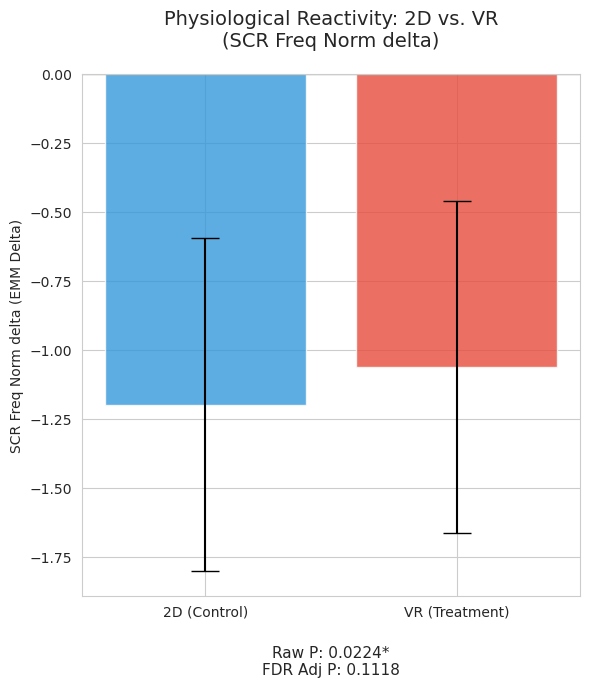



--- Contrasts and Effect Sizes: (SCR Freq Norm delta) ---
                  Effect  Coefficient                 Std.Err    z-stat  \
0              Intercept    -1.196773   [0.30785044275552487] -3.887515   
1        Condition[T.VR]     0.136366  [0.059698140508815806]  2.284261   
2      vrfirst[T.VRlast]    -0.143828     [0.354459979033828] -0.405768   
3  abbafirst[T.ABBAlast]    -0.053836    [0.3526727534334524] -0.152651   
4        Phase[T.phase2]    -0.096824    [0.0596981405088158] -1.621897   

                  p-value  r_effect  d_effect  
0  0.00010127587020809945  0.533424 -1.261276  
1    0.022356181870989245  0.347468  0.741112  
2      0.6849131623430418  0.065682 -0.131648  
3      0.8786733706803306  0.024756 -0.049527  
4     0.10482550346202622  0.254447 -0.526213  


Standardized Beta for SCR_Freq_Norm_delta: 26.785


--- Confidence Intervals: (SCR Freq Norm delta) ---
                       Lower 95%  Upper 95%      Coef
Intercept              -1.800149  -0.5933

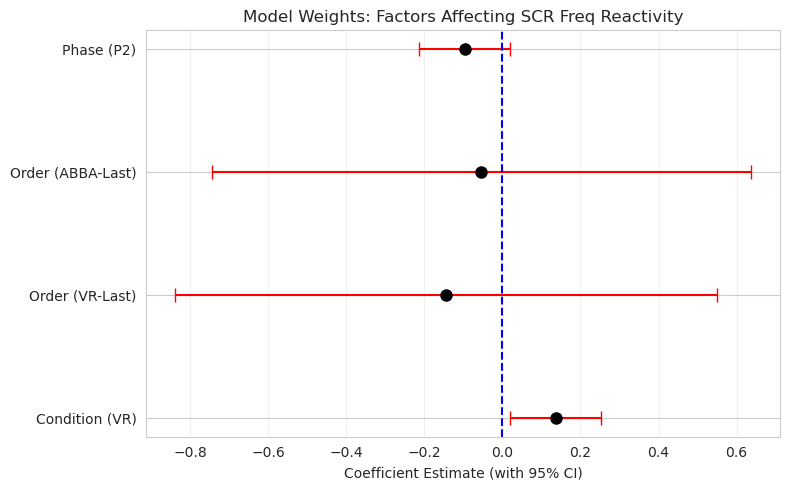

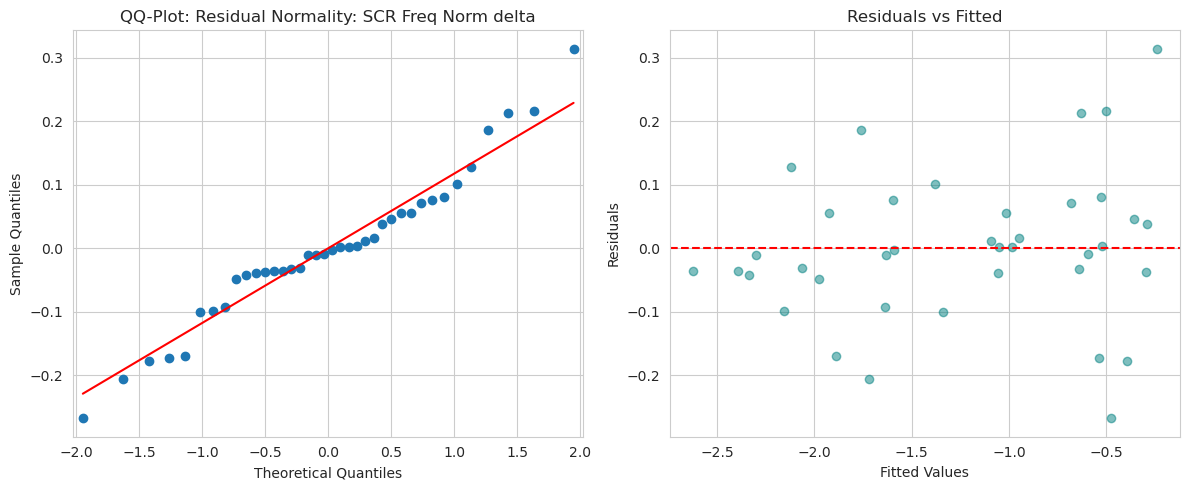

=== Statsmodels Linear Mixed Model EDA_Sympathetic_Norm_delta ~ Condition + vrfirst + abbafirst + Phase ===
                 Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: EDA_Sympathetic_Norm_delta
No. Observations: 38      Method:             REML                      
No. Groups:       20      Scale:              0.0000                    
Min. group size:  1       Log-Likelihood:     129.3464                  
Max. group size:  2       Converged:          Yes                       
Mean group size:  1.9                                                   
-------------------------------------------------------------------------
                          Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-------------------------------------------------------------------------
Intercept                 -0.002     0.002  -1.209  0.227  -0.006   0.001
Condition[T.VR]            0.001     0.001   1.730  0.084  -0.000   0.003
vrfirst[T.VRlast]          0.

/home/ireguero/.local/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


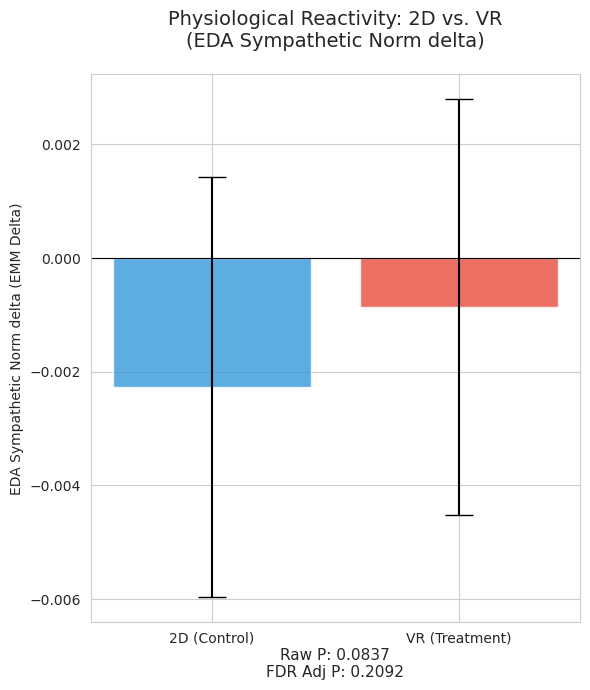



--- Contrasts and Effect Sizes: (EDA Sympathetic Norm delta) ---
                  Effect  Coefficient                  Std.Err    z-stat  \
0              Intercept    -0.002273  [0.0018808114147992087] -1.208563   
1        Condition[T.VR]     0.001406  [0.0008126165562875727]  1.729767   
2      vrfirst[T.VRlast]     0.001495  [0.0020810700604673165]  0.718343   
3  abbafirst[T.ABBAlast]     0.000429  [0.0020703444689849073]  0.207427   
4        Phase[T.phase2]     0.000683  [0.0008126165562875726]  0.840530   

               p-value  r_effect  d_effect  
0  0.22683081923077741  0.192392 -0.392110  
1  0.08367192240836499  0.270170  0.561211  
2   0.4725459439873889  0.115747  0.233061  
3   0.8356763273795955  0.033630  0.067298  
4  0.40061106422242754  0.135102  0.272704  


Standardized Beta for EDA_Sympathetic_Norm_delta: 0.276


--- Confidence Intervals: (EDA Sympathetic Norm delta) ---
                       Lower 95%  Upper 95%      Coef
Intercept              -0.005959 

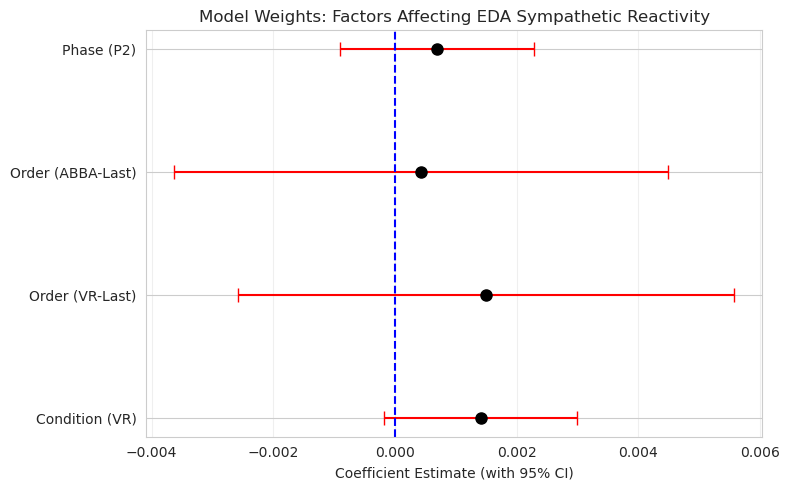

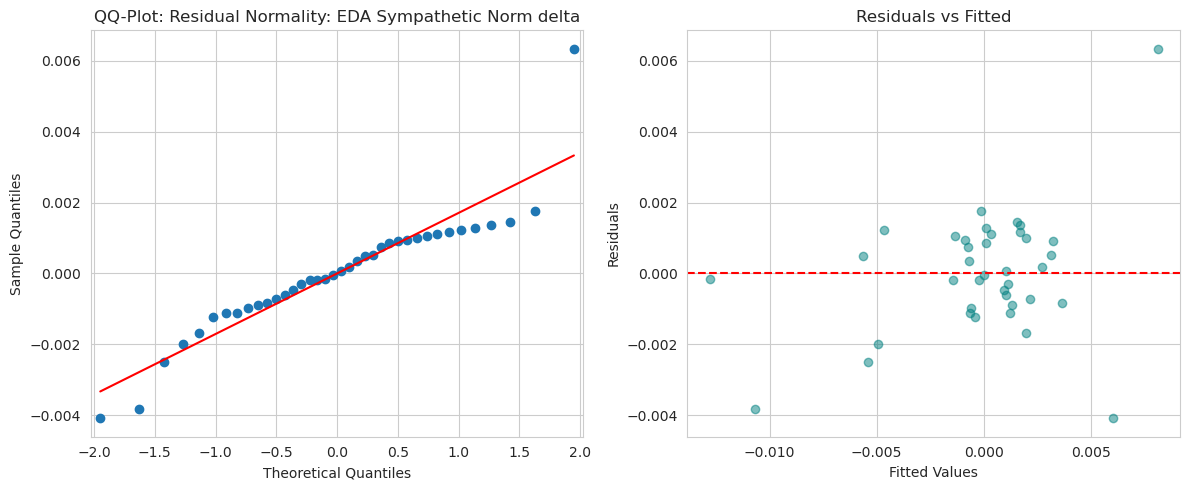

=== Statsmodels Linear Mixed Model HRV_RMSSD_Norm_delta ~ Condition + vrfirst + abbafirst + Phase ===
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: HRV_RMSSD_Norm_delta
No. Observations: 38      Method:             REML                
No. Groups:       20      Scale:              0.1108              
Min. group size:  1       Log-Likelihood:     -20.5641            
Max. group size:  2       Converged:          Yes                 
Mean group size:  1.9                                             
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                0.046    0.141  0.327 0.744 -0.230  0.323
Condition[T.VR]         -0.066    0.110 -0.604 0.546 -0.281  0.149
vrfirst[T.VRlast]       -0.093    0.137 -0.676 0.499 -0.361  0.176
abbafirst[T.ABBAlast]    0.023    0.136  0

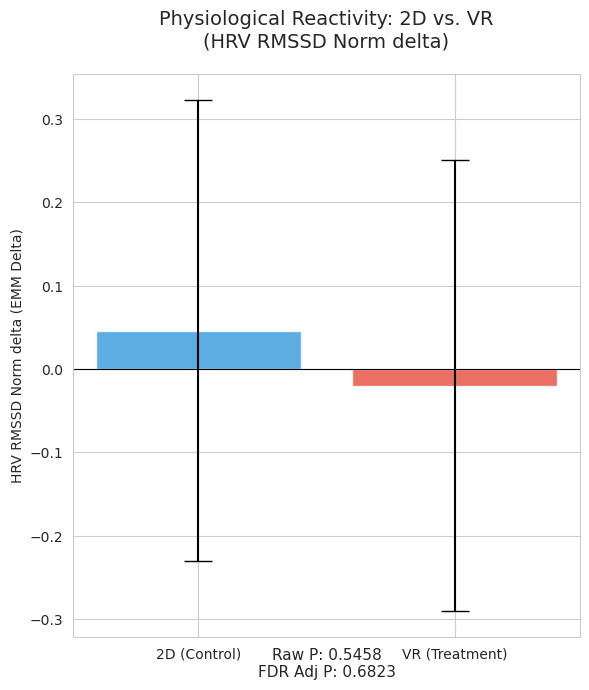



--- Contrasts and Effect Sizes: (HRV RMSSD Norm delta) ---
                  Effect  Coefficient                Std.Err    z-stat  \
0              Intercept     0.046188   [0.1411594248001287]  0.327207   
1        Condition[T.VR]    -0.066206  [0.10960309482003816] -0.604050   
2      vrfirst[T.VRlast]    -0.092523   [0.1369183630830769] -0.675753   
3  abbafirst[T.ABBAlast]     0.023421  [0.13614988190309488]  0.172027   
4        Phase[T.phase2]     0.190682  [0.10960309482003816]  1.739749   

               p-value  r_effect  d_effect  
0   0.7435111311841986  0.053005  0.106160  
1   0.5458103691918902  0.097523 -0.195980  
2   0.4991972432906162  0.108969 -0.219243  
3   0.8634164045344538  0.027896  0.055813  
4  0.08190315903050777  0.271615  0.564449  


Standardized Beta for HRV_RMSSD_Norm_delta: -13.004


--- Confidence Intervals: (HRV RMSSD Norm delta) ---
                       Lower 95%  Upper 95%      Coef
Intercept              -0.230479   0.322856  0.046188
Conditi

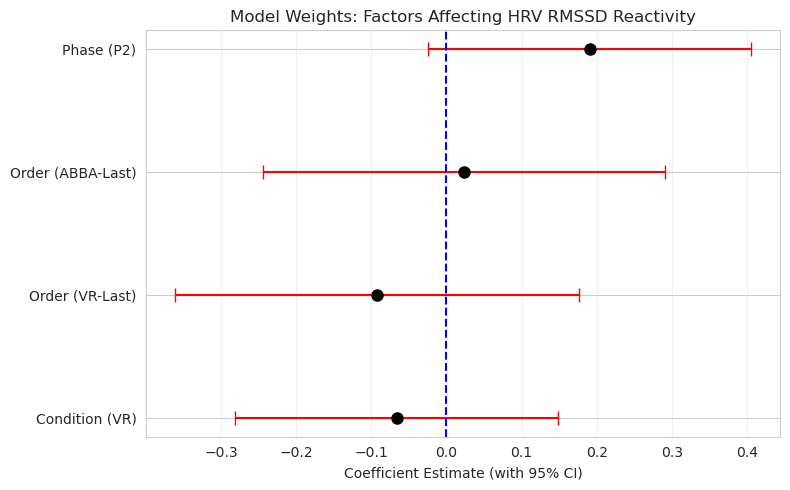

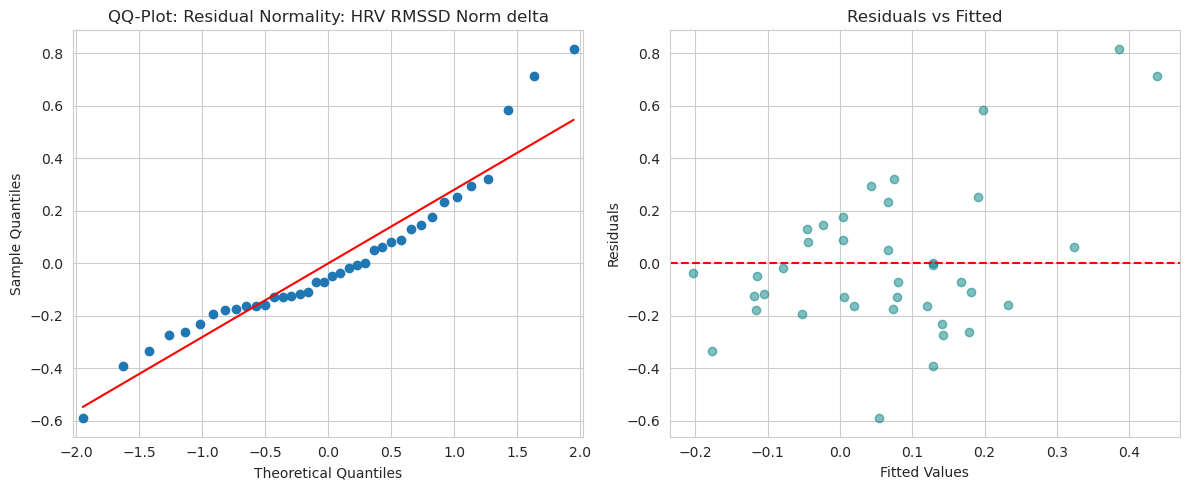

--- FDR (Benjamini-Hochberg) for main metrics ---
                       Metric     Raw_P  Adjusted_P  Significant
0         SCR_Freq_Norm_delta  0.022356    0.067069        False
1  EDA_Sympathetic_Norm_delta  0.083672    0.125508        False
2        HRV_RMSSD_Norm_delta  0.545810    0.545810        False


--- VIF Report ---
              feature       VIF
0               const  5.047518
1        Condition_VR  1.008740
2      vrfirst_VRlast  1.008207
3  abbafirst_ABBAlast  1.008140
4        Phase_phase2  1.008740


--- Descriptive statistics report for the key metrics (normalized) ---
                  SCR_Freq_Norm_delta        EDA_Sympathetic_Norm_delta  \
                                 mean    std                       mean   
vrfirst Condition                                                         
VRfirst 2D                     -1.204  0.933                     -0.001   
        VR                     -1.086  0.981                     -0.001   
VRlast  2D                   

0

In [116]:
main()